# Business Understanding

The laptop market is highly competitive, with multiple brands offering a range of models at different price points. Consumers make purchasing decisions based on key factors such as the brand, processor speed, RAM size, storage capacity, screen size, and weight. Understanding how these factors impact the price of laptops is critical for both consumers and businesses involved in the manufacturing, marketing, and sales of laptops. The goal is to predict laptop prices accurately and derive actionable insights into how various features influence the price. By doing so, manufacturers, retailers, and consumers can make more informed decisions regarding product development, marketing strategies, and pricing.

## Project Domain

The domain of this project is predictive modeling and price analysis within the technology and consumer electronics industry, particularly focusing on laptops. The project falls under the broader field of data science and machine learning, where the task is to build models that predict outcomes (in this case, laptop prices) based on input features such as hardware specifications and other product attributes. It involves understanding how technical specifications, such as the processor speed, RAM size, and storage capacity, influence the pricing structure of laptops in the marketplace.

## Problem Statements



*   Price Prediction Accuracy: Predicting the price of a laptop based on its
specifications can be challenging due to the presence of various features that interact with each other in complex ways.

*   Feature Impact Understanding: While certain laptop features (like brand and processor speed) are commonly believed to influence price, the exact relationship between these variables is unclear and may vary across brands.

*   Market Segmentation: The laptop market consists of different segments, from budget-friendly to high-end models. Understanding which features distinguish these segments is critical for pricing strategies.

*   Noise in Data: The dataset includes simulated prices with added noise, which means there is a need to develop models that can generalize well even with noisy data.

## Goals



1.   *Price Prediction Model* = Develop a machine learning model that accurately predicts the price of a laptop based on its specifications (brand, processor speed, RAM, storage capacity, screen size, and weight).

2.   *Feature Impact Analysis* = Analyze the impact of individual features on the price of a laptop. For example, assess how much processor speed or RAM size contributes to an increase in laptop price.

3.   *Price Segmentation* =  Identify distinct market segments based on the price points and features of laptops. Classify laptops into low, medium, and high-end segments to understand how different features influence pricing within each segment.

4.   *Data Exploration and Preprocessing* = Clean the data, handle missing or noisy values, and ensure that the dataset is ready for building predictive models.


## Solution Statements

1.   Predictive Modeling =
Implement a Linear Regression model or other suitable machine learning algorithms to predict laptop prices based on the available features. The model will be trained using historical laptop data and will be evaluated using performance metrics such as Root Mean Squared Error (RMSE) to ensure its accuracy.
---

2.   Feature Impact Analysis =
Use statistical techniques and machine learning models to identify the most influential features in determining laptop prices. For example, feature importance from tree-based models or regression coefficients can be used to rank the impact of each feature.

---

3.   Price Segmentation =
Use clustering algorithms (such as K-Means Clustering) to group laptops into different pricing segments based on their features. This segmentation will allow for better understanding of the price categories in the market and help identify what features define each segment.

---

4.   Data Preprocessing =
Clean and preprocess the dataset by handling any missing or noisy values, converting categorical features (like brand) into numerical values (using techniques like one-hot encoding), and scaling numerical features to ensure they are on a similar scale, which is essential for most machine learning models.

# Data Understanding

## Import data dari kaggle

In [2]:
!pip install kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"reizzz","key":"8142c2b8ac2dce785e96330f0cd407ad"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [5]:
!kaggle datasets download -d mrsimple07/laptoppriceprediction

Dataset URL: https://www.kaggle.com/datasets/mrsimple07/laptoppriceprediction
License(s): apache-2.0


In [6]:
!mkdir laptoppriceprediction
!unzip laptoppriceprediction.zip -d laptoppriceprediction
!ls laptoppriceprediction

Archive:  laptoppriceprediction.zip
  inflating: laptoppriceprediction/Laptop_price.csv  
Laptop_price.csv


## Import Library yang dibutuhkan

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

## Exploratory Data Analysis

In [77]:
df = pd.read_csv('/content/laptoppriceprediction/Laptop_price.csv')

In [78]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


In [79]:
print("Missing Value in each column:")
print(df.isnull().sum())

Missing Value in each column:
Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64


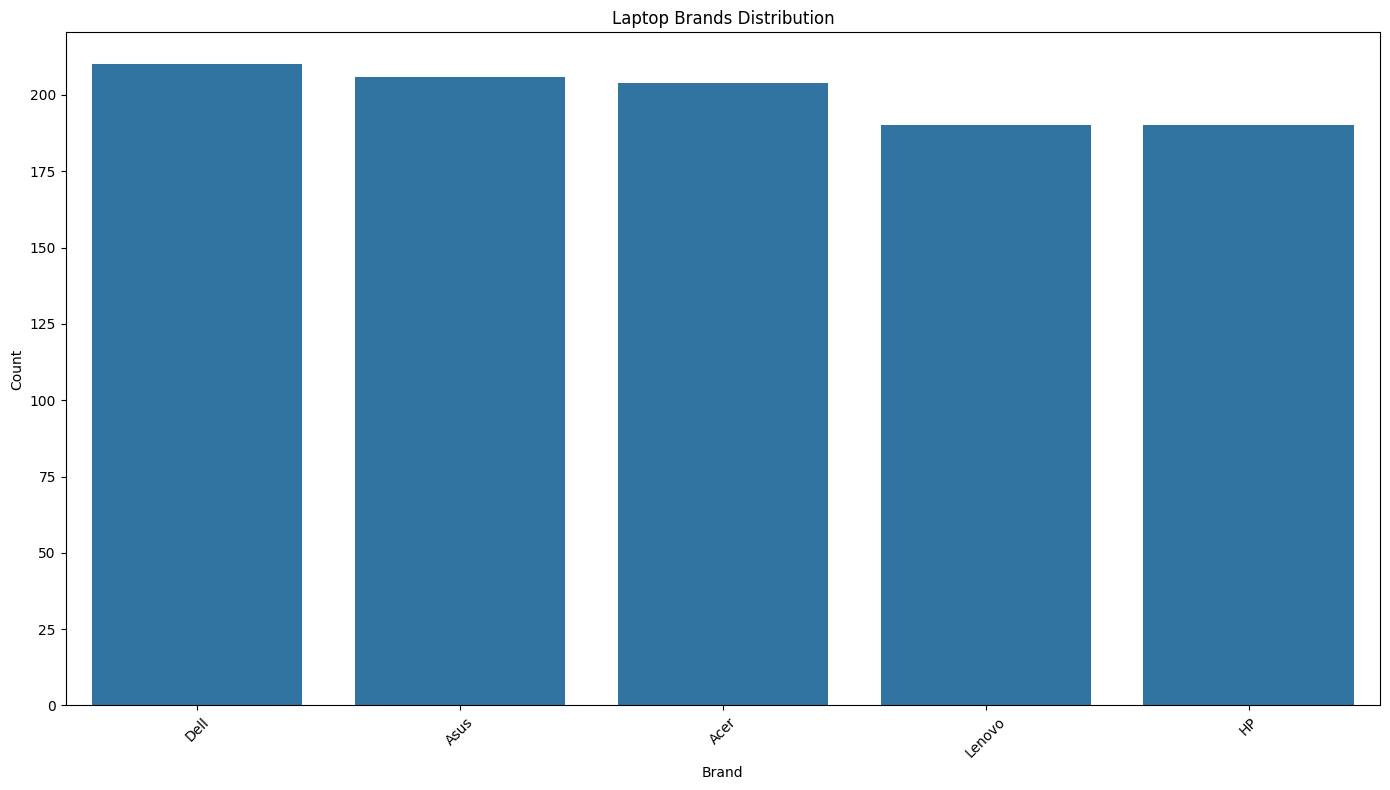

In [80]:
# Brand Distribution Analysis
plt.figure(figsize=(14, 8))
brand_counts = df['Brand'].value_counts()
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.title('Laptop Brands Distribution')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

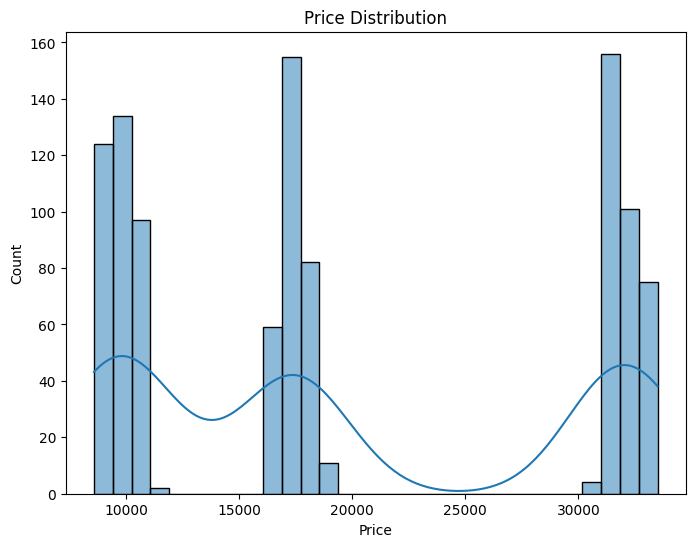

In [81]:
# Plot the distribution of the 'Price' column
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], kde=True, bins=30)
plt.title("Price Distribution")
plt.show()


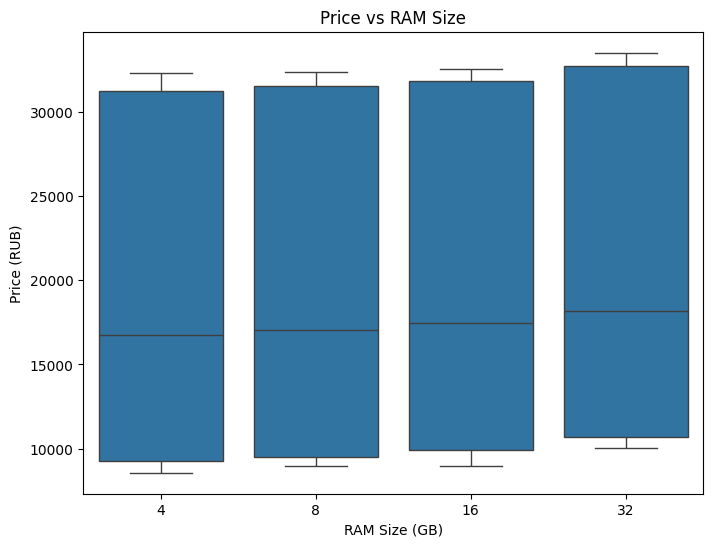

In [82]:
# Boxplot of 'Price' vs 'RAM Size'
plt.figure(figsize=(8, 6))
sns.boxplot(x='RAM_Size', y='Price', data=df)
plt.title("Price vs RAM Size")
plt.xlabel('RAM Size (GB)')
plt.ylabel('Price (RUB)')
plt.show()

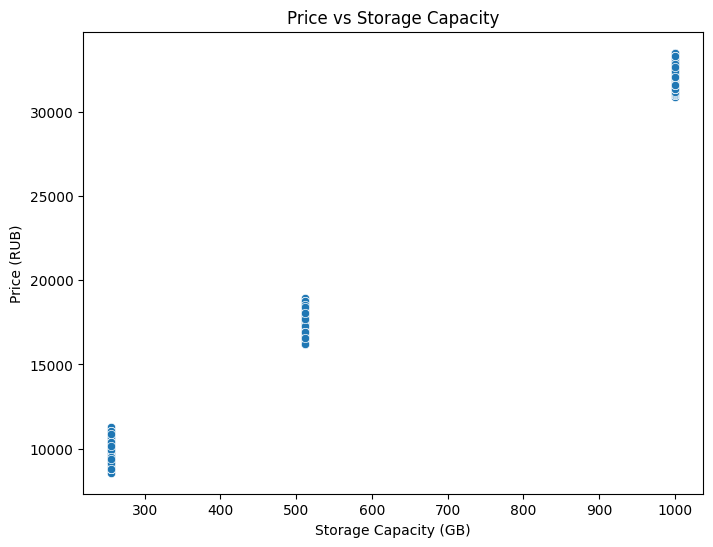

In [83]:
# Scatter plot of 'Price' vs 'Storage Capacity'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Storage_Capacity', y='Price', data=df)
plt.title("Price vs Storage Capacity")
plt.xlabel('Storage Capacity (GB)')
plt.ylabel('Price (RUB)')
plt.show()


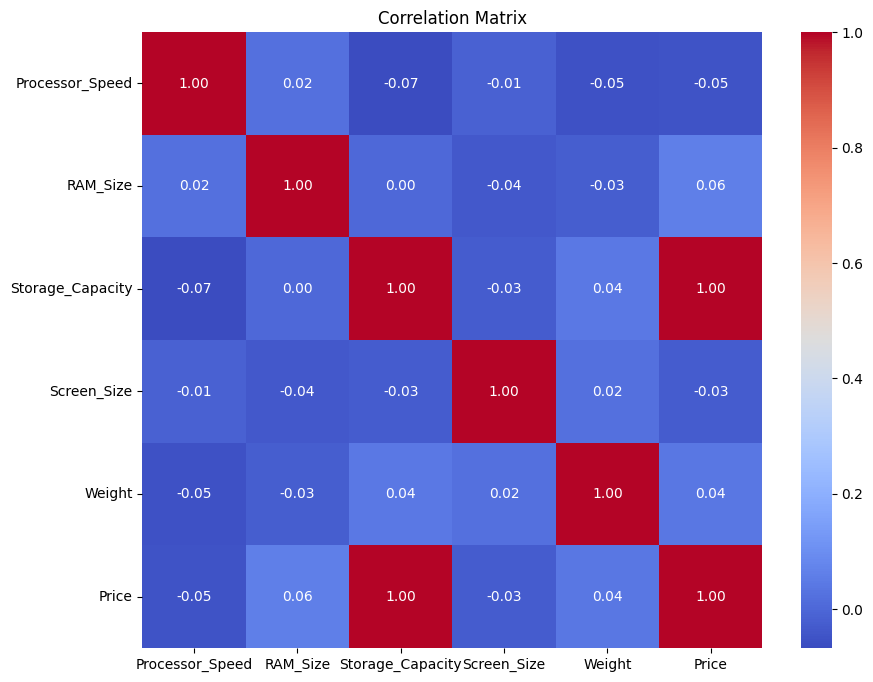

In [84]:
# Correlation matrix plot
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Data Preparation

In [85]:
# One-hot encode the categorical columns (Brand)
df_encoded = pd.get_dummies(df, columns=['Brand'])

In [86]:
# Separate features (X) and target variable (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

In [87]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modeling

In [89]:
# Initialize the ANN model
model = Sequential()
model.add(Dense(units=64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

In [91]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 454019584.0000 - mean_absolute_error: 19168.8867 - val_loss: 467776768.0000 - val_mean_absolute_error: 19415.9473
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 474730688.0000 - mean_absolute_error: 19650.8555 - val_loss: 467634880.0000 - val_mean_absolute_error: 19412.3555
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 476876608.0000 - mean_absolute_error: 19717.5840 - val_loss: 467352448.0000 - val_mean_absolute_error: 19405.4043
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 481136096.0000 - mean_absolute_error: 19844.7520 - val_loss: 466835552.0000 - val_mean_absolute_error: 19392.9727
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 483968256.0000 - mean_absolute_error: 19888.0273 - val_loss: 465966368.0000 - val_mean_absolute_error: 19372.4453
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 458953728.0000 - mean_absolute_error: 19363.0781 - val_loss: 464624160.0000 - val

# Evaluation

In [92]:
# Predict the prices on the test set
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step



Evaluation Metrics:
Mean Absolute Error (MAE): 1803.35
Mean Squared Error (MSE): 5280116.24
Root Mean Squared Error (RMSE): 2297.85
R-squared (R²): 0.94


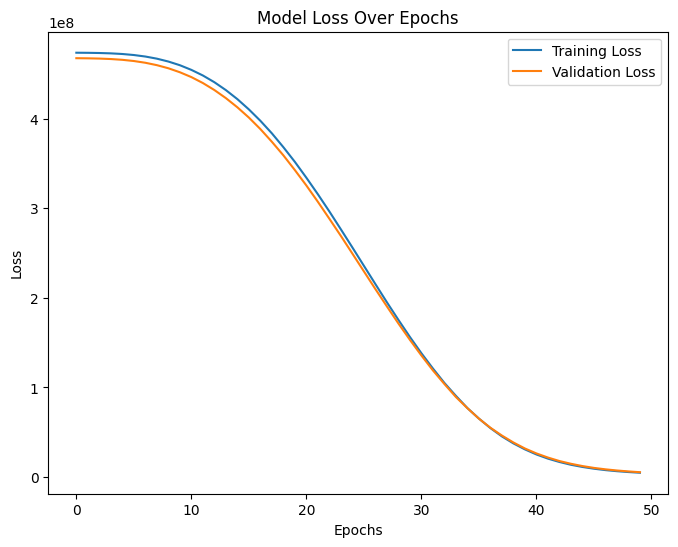

In [93]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"\nEvaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Plot training and validation loss over epochs
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Deployment

## Model Simulation

In [94]:
# Simulate model prediction with example input
new_laptop = np.array([[3.5, 16, 512, 15.6, 2.3, 0, 1, 0, 0, 0]])  # Example with 'Asus' brand
new_laptop_scaled = scaler.transform(new_laptop)
predicted_price = model.predict(new_laptop_scaled)
print(f"Simulated Price for Example Input: ₽{predicted_price_example[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Simulated Price for Example Input: ₽15,967.30


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Save Model

In [60]:
# Save the trained model to a file
model.save('/content/laptop_price_model.h5')


In [61]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)